In [1]:
# ============================================================
# CELL 1 — Import Libraries + Load Everything from Phase 4
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scorecardpy as sc
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# --- Load master features ---
df = pd.read_csv('../data/master_features.csv')
print(f"✅ master_features.csv loaded — shape: {df.shape}")

# --- Load models ---
lr      = joblib.load('../models/logistic_regression.pkl')
scaler  = joblib.load('../models/scaler.pkl')
label_encoders = joblib.load('../models/label_encoders.pkl')

with open('../models/feature_names.json', 'r') as f:
    feature_names = json.load(f)

print(f"✅ Logistic Regression loaded")
print(f"✅ Scaler loaded")
print(f"✅ Label encoders loaded")
print(f"✅ Feature names loaded — {len(feature_names)} features")

# --- Reconstruct X and y ---
X = df[feature_names].copy()
y = df['TARGET'].copy()

# --- Encode categoricals (same as Phase 4) ---
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if col in label_encoders:
        X[col] = label_encoders[col].transform(X[col].astype(str))

print(f"\n✅ X reconstructed — shape: {X.shape}")
print(f"✅ y reconstructed — default rate: {y.mean():.4f}")

# --- Verify LR coefficients are accessible ---
print(f"\n📋 LR Model Info:")
print(f"   Intercept : {lr.intercept_[0]:.4f}")
print(f"   Features  : {len(lr.coef_[0])}")
print(f"   Coef range: {lr.coef_[0].min():.4f} to {lr.coef_[0].max():.4f}")

✅ master_features.csv loaded — shape: (307511, 26)
✅ Logistic Regression loaded
✅ Scaler loaded
✅ Label encoders loaded
✅ Feature names loaded — 24 features

✅ X reconstructed — shape: (307511, 24)
✅ y reconstructed — default rate: 0.0807

📋 LR Model Info:
   Intercept : -0.2539
   Features  : 24
   Coef range: -0.5863 to 0.2084


In [3]:
# ============================================================
# CELL 2 (FIXED) — Scorecard Scaling with Correct Orientation
# ============================================================

PDO    = 20
ODDS   = 1
FACTOR = PDO / np.log(2)
OFFSET = 600 - FACTOR * np.log(ODDS)

X_scaled = scaler.transform(X)

# ── FIXED: negate log_odds so higher score = safer borrower ──
log_odds = lr.intercept_[0] + X_scaled.dot(lr.coef_[0])
scores_raw = OFFSET + FACTOR * (-log_odds)   # ← negative sign added

# Clip to 300-900 range
scores = np.clip(scores_raw, 300, 900).round().astype(int)

print(f"📊 Score Distribution (Full Dataset):")
print(f"   Min score  : {scores.min()}")
print(f"   Max score  : {scores.max()}")
print(f"   Mean score : {scores.mean():.1f}")
print(f"   Std score  : {scores.std():.1f}")

df['CREDIT_SCORE'] = scores

print(f"\n📊 Score by TARGET:")
print(df.groupby('TARGET')['CREDIT_SCORE'].describe().round(1))

# Quick sanity check
repaid_mean    = df[df['TARGET']==0]['CREDIT_SCORE'].mean()
defaulted_mean = df[df['TARGET']==1]['CREDIT_SCORE'].mean()
print(f"\n✅ Sanity Check:")
print(f"   Repaid mean score    : {repaid_mean:.1f}  ← should be HIGHER")
print(f"   Defaulted mean score : {defaulted_mean:.1f}  ← should be LOWER")

if repaid_mean > defaulted_mean:
    print(f"   Orientation CORRECT ✅ — higher score = safer borrower")
else:
    print(f"   Orientation WRONG ❌")

📊 Score Distribution (Full Dataset):
   Min score  : 468
   Max score  : 869
   Mean score : 612.0
   Std score  : 29.5

📊 Score by TARGET:
             count     mean     std      min      25%      50%      75%  \
TARGET                                                                    
0      282686.0000 613.8000 28.7000 478.0000 595.0000 616.0000 634.0000   
1       24825.0000 591.4000 30.9000 468.0000 571.0000 592.0000 613.0000   

            max  
TARGET           
0      869.0000  
1      698.0000  

✅ Sanity Check:
   Repaid mean score    : 613.8  ← should be HIGHER
   Defaulted mean score : 591.4  ← should be LOWER
   Orientation CORRECT ✅ — higher score = safer borrower


📊 Risk Tier Distribution:
-------------------------------------------------------
  Low Risk           | Count:  28,049 (  9.1%) | Default Rate:  2.01%
  Medium Risk        | Count: 181,303 ( 59.0%) | Default Rate:  5.26%
  High Risk          | Count:  90,488 ( 29.4%) | Default Rate: 13.72%
  Very High Risk     | Count:   7,671 (  2.5%) | Default Rate: 30.09%
-------------------------------------------------------


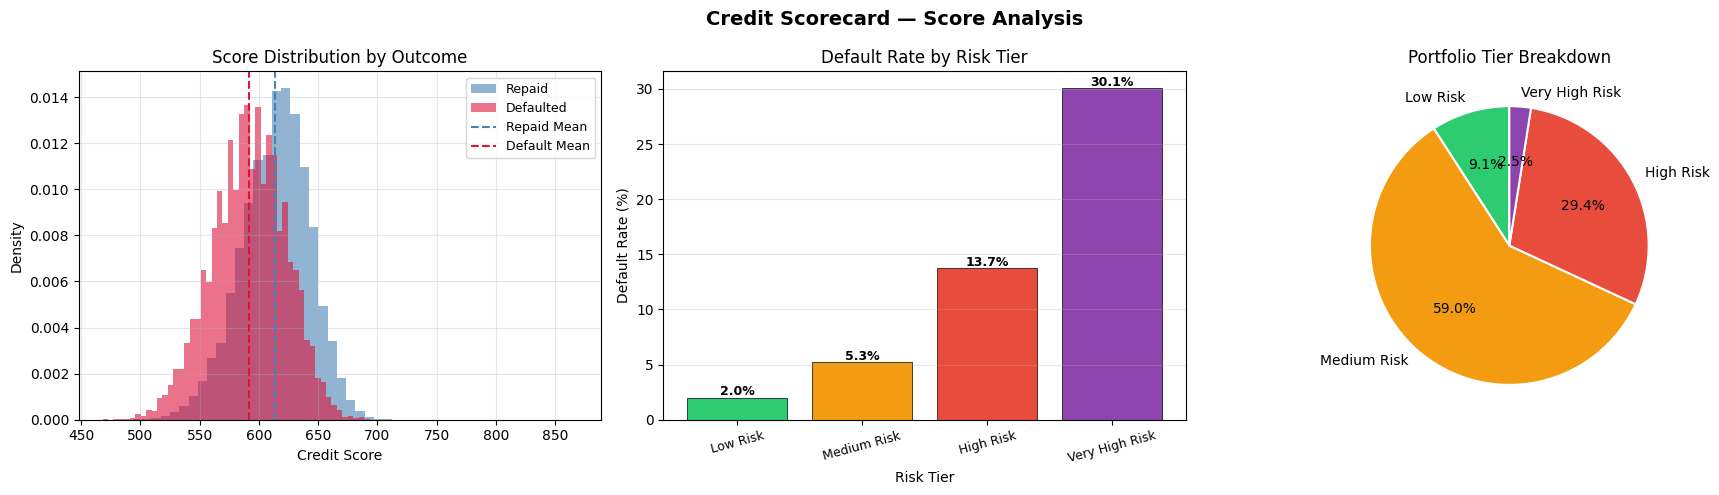

✅ Saved → models/scorecard_analysis.png


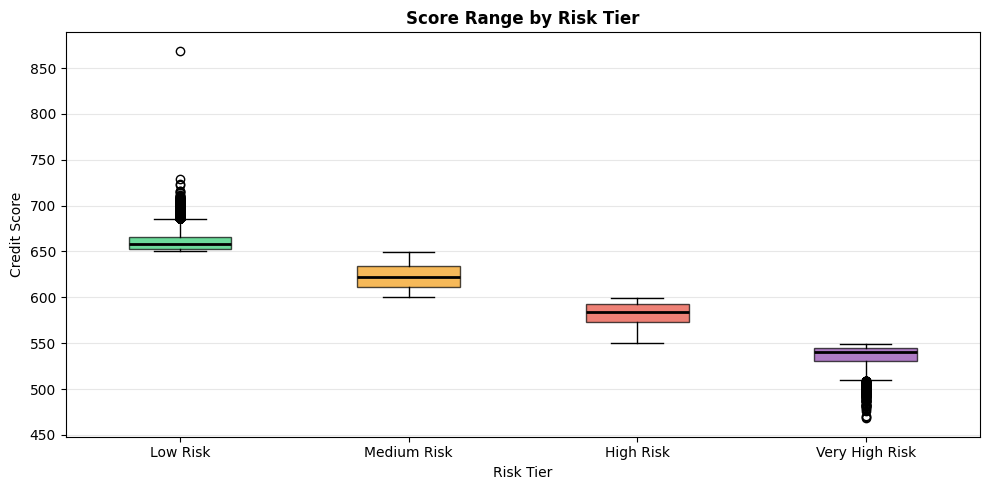

✅ Saved → models/scorecard_boxplot.png


In [4]:
# ============================================================
# CELL 3 — Assign Risk Tiers + Visualize Score Distribution
# ============================================================

# ── Risk Tier Mapping ─────────────────────────────────────────
# Industry standard cutoffs (same logic as CIBIL/FICO tiers)
def assign_risk_tier(score):
    if score >= 650:
        return 'Low Risk'
    elif score >= 600:
        return 'Medium Risk'
    elif score >= 550:
        return 'High Risk'
    else:
        return 'Very High Risk'

df['RISK_TIER'] = df['CREDIT_SCORE'].apply(assign_risk_tier)

# ── Tier Summary ──────────────────────────────────────────────
tier_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
tier_colors = {
    'Low Risk'      : '#2ecc71',
    'Medium Risk'   : '#f39c12',
    'High Risk'     : '#e74c3c',
    'Very High Risk': '#8e44ad'
}

print("📊 Risk Tier Distribution:")
print("-" * 55)
for tier in tier_order:
    subset       = df[df['RISK_TIER'] == tier]
    count        = len(subset)
    pct          = count / len(df) * 100
    default_rate = subset['TARGET'].mean() * 100
    print(f"  {tier:<18} | Count: {count:>7,} ({pct:>5.1f}%) "
          f"| Default Rate: {default_rate:>5.2f}%")
print("-" * 55)

# ── Plot 1: Score Distribution by TARGET ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Credit Scorecard — Score Analysis', 
             fontsize=14, fontweight='bold')

# Histogram — repaid vs defaulted
ax1 = axes[0]
ax1.hist(df[df['TARGET']==0]['CREDIT_SCORE'], bins=50,
         alpha=0.6, color='steelblue', label='Repaid', density=True)
ax1.hist(df[df['TARGET']==1]['CREDIT_SCORE'], bins=50,
         alpha=0.6, color='crimson',   label='Defaulted', density=True)
ax1.axvline(613.8, color='steelblue', linestyle='--', lw=1.5, label='Repaid Mean')
ax1.axvline(591.4, color='crimson',   linestyle='--', lw=1.5, label='Default Mean')
ax1.set_xlabel('Credit Score')
ax1.set_ylabel('Density')
ax1.set_title('Score Distribution by Outcome')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bar chart — default rate by risk tier
ax2 = axes[1]
tier_default_rates = [
    df[df['RISK_TIER']==tier]['TARGET'].mean() * 100
    for tier in tier_order
]
bars = ax2.bar(tier_order, tier_default_rates,
               color=[tier_colors[t] for t in tier_order],
               edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Risk Tier')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate by Risk Tier')
ax2.set_xticklabels(tier_order, rotation=15, fontsize=9)
for bar, val in zip(bars, tier_default_rates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Pie chart — tier population breakdown
ax3 = axes[2]
tier_counts = [len(df[df['RISK_TIER']==tier]) for tier in tier_order]
ax3.pie(tier_counts,
        labels=tier_order,
        colors=[tier_colors[t] for t in tier_order],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax3.set_title('Portfolio Tier Breakdown')

plt.tight_layout()
plt.savefig('../models/scorecard_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → models/scorecard_analysis.png")

# ── Plot 2: Score Boxplot by Risk Tier ───────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))
tier_data = [df[df['RISK_TIER']==tier]['CREDIT_SCORE'].values 
             for tier in tier_order]
bp = ax.boxplot(tier_data, labels=tier_order, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.7)
ax.set_xlabel('Risk Tier')
ax.set_ylabel('Credit Score')
ax.set_title('Score Range by Risk Tier', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../models/scorecard_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → models/scorecard_boxplot.png")

In [6]:
# ============================================================
# CELL 4 — Per-Feature Score Points Breakdown
# ============================================================

# Each feature contributes a number of points to the final score
# Formula: points_i = FACTOR * coef_i * scaled_feature_value
# This shows WHICH features added/subtracted points per applicant

# ── Feature-level point contributions ────────────────────────
coefs         = lr.coef_[0]
X_scaled_full = scaler.transform(X)

# Points matrix — each cell = points this feature gave this applicant
points_matrix = FACTOR * coefs * X_scaled_full
points_df     = pd.DataFrame(points_matrix, columns=feature_names)

print("📊 Average Point Contribution per Feature:")
print("-" * 50)
avg_points = points_df.mean().sort_values()
for feat, pts in avg_points.items():
    bar = '█' * int(abs(pts) * 2)
    direction = '▲' if pts > 0 else '▼'
    print(f"  {feat:<30} {direction} {pts:>+7.2f} pts  {bar}")
print("-" * 50)
print(f"  Intercept contribution : {FACTOR * lr.intercept_[0]:>+7.2f} pts")
print(f"  Base offset            : {OFFSET:>+7.2f} pts")

# ── Sample Scorecard Report for 5 applicants ─────────────────
print("\n" + "=" * 60)
print("       SAMPLE SCORECARD REPORTS — 5 APPLICANTS")
print("=" * 60)

# Pick 1 from each tier
samples = {}
for tier in tier_order:
    idx = df[df['RISK_TIER'] == tier].index[0]
    samples[tier] = idx

for tier, idx in samples.items():
    score     = df.loc[idx, 'CREDIT_SCORE']
    actual    = df.loc[idx, 'TARGET']
    actual_str = 'Defaulted' if actual == 1 else 'Repaid'
    top_feats = points_df.loc[idx].abs().sort_values(ascending=False).head(5)

    print(f"\n  Applicant #{idx} — {tier}")
    print(f"  Credit Score : {score}  |  Actual Outcome: {actual_str}")
    print(f"  Top 5 driving features:")
    for feat, pts in points_df.loc[idx][top_feats.index].items():
        direction = '↑ helped' if pts > 0 else '↓ hurt'
        print(f"    {feat:<30} {pts:>+7.2f} pts  {direction}")
    print(f"  {'─'*50}")

# ── Save points breakdown ─────────────────────────────────────
points_df['CREDIT_SCORE'] = df['CREDIT_SCORE']
points_df['RISK_TIER']    = df['RISK_TIER']
points_df['TARGET']       = df['TARGET']
points_df.to_csv('../models/scorecard_points.csv', index=False)
print("\n✅ Saved → models/scorecard_points.csv")

📊 Average Point Contribution per Feature:
--------------------------------------------------
  EXT_SOURCE_2                   ▼   -1.51 pts  ███
  EXT_SOURCE_3                   ▼   -1.15 pts  ██
  EXT_SOURCE_1                   ▼   -0.48 pts  
  REGION_RATING_CLIENT           ▼   -0.30 pts  
  CODE_GENDER                    ▼   -0.28 pts  
  NAME_FAMILY_STATUS             ▼   -0.25 pts  
  AGE_EMPLOYMENT_RATIO           ▼   -0.17 pts  
  AGE_YEARS                      ▼   -0.13 pts  
  PREV_APPROVAL_RATE             ▼   -0.10 pts  
  PREV_REFUSED_COUNT             ▼   -0.08 pts  
  BUREAU_ACTIVE_RATIO            ▼   -0.05 pts  
  AMT_CREDIT                     ▼   -0.05 pts  
  ANNUITY_INCOME_RATIO           ▼   -0.03 pts  
  DOCUMENTS_SUBMITTED            ▼   -0.03 pts  
  NAME_EDUCATION_TYPE            ▼   -0.02 pts  
  CREDIT_INCOME_RATIO            ▼   -0.02 pts  
  EXT_SOURCE_MIN                 ▼   -0.02 pts  
  NAME_INCOME_TYPE               ▼   -0.00 pts  
  BUREAU_TOTAL_DEBT 

In [7]:
# ============================================================
# CELL 5 — Save Scorecard Output + Phase 5 Final Summary
# ============================================================
import os

# ── Save scored dataset ───────────────────────────────────────
scored_df = df[['SK_ID_CURR', 'TARGET', 'CREDIT_SCORE', 'RISK_TIER']].copy()
scored_df.to_csv('../models/scored_applicants.csv', index=False)
print("✅ Saved → models/scored_applicants.csv")

# ── Save scaling parameters (needed in Streamlit) ─────────────
import json
scorecard_params = {
    'PDO'    : PDO,
    'ODDS'   : ODDS,
    'FACTOR' : FACTOR,
    'OFFSET' : OFFSET,
    'score_min' : 300,
    'score_max' : 900,
    'tiers' : {
        'Low Risk'      : {'min': 650, 'max': 900,  'color': '#2ecc71'},
        'Medium Risk'   : {'min': 600, 'max': 649,  'color': '#f39c12'},
        'High Risk'     : {'min': 550, 'max': 599,  'color': '#e74c3c'},
        'Very High Risk': {'min': 300, 'max': 549,  'color': '#8e44ad'}
    }
}

with open('../models/scorecard_params.json', 'w') as f:
    json.dump(scorecard_params, f, indent=4)
print("✅ Saved → models/scorecard_params.json")

# ── Verify all Phase 5 files exist ───────────────────────────
print("\n📁 All files in models/ folder:")
for fname in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{fname}') / 1024
    print(f"   {fname:<40} {size:.1f} KB")

# ── Final Phase 5 Summary ─────────────────────────────────────
print("\n" + "=" * 58)
print("          PHASE 5 COMPLETE — SCORECARD SUMMARY")
print("=" * 58)

print(f"""
  Method       : Points to Double Odds (PDO=20, Base=600)
  Scale        : 300 – 900  (CIBIL-style)
  Score Range  : {df['CREDIT_SCORE'].min()} – {df['CREDIT_SCORE'].max()}
  Mean Score   : {df['CREDIT_SCORE'].mean():.1f}

  Risk Tier Breakdown:
  ┌─────────────────┬──────────┬──────────────┐
  │ Tier            │ Population│ Default Rate │
  ├─────────────────┼──────────┼──────────────┤""")

for tier in tier_order:
    subset  = df[df['RISK_TIER'] == tier]
    pct     = len(subset) / len(df) * 100
    def_rate= subset['TARGET'].mean() * 100
    print(f"  │ {tier:<15} │ {pct:>7.1f}% │ {def_rate:>10.2f}% │")

print(f"""  └─────────────────┴──────────┴──────────────┘

  Files saved  : 7 files in models/
  Plots saved  : 4 PNGs in models/
""")

print("=" * 58)
print("""
  Phases Complete:
    Phase 1 — Data Understanding     ✅
    Phase 2 — EDA                    ✅
    Phase 3 — Feature Engineering    ✅
    Phase 4 — Modeling               ✅
    Phase 5 — Scorecard Creation     ✅
  ─────────────────────────────────────
    Phase 6 — Streamlit Deployment   ← NEXT
    Phase 7 — GitHub + README
""")
print("=" * 58)

✅ Saved → models/scored_applicants.csv
✅ Saved → models/scorecard_params.json

📁 All files in models/ folder:
   feature_names.json                       0.5 KB
   label_encoders.pkl                       1.5 KB
   logistic_regression.pkl                  1.0 KB
   roc_curve_combined.png                   90.1 KB
   roc_curve_comparison.png                 130.9 KB
   scaler.pkl                               1.9 KB
   scorecard_analysis.png                   140.5 KB
   scorecard_boxplot.png                    42.5 KB
   scorecard_params.json                    0.6 KB
   scorecard_points.csv                     146653.3 KB
   scored_applicants.csv                    7571.5 KB
   shap_beeswarm.png                        246.9 KB
   shap_importance_bar.png                  124.2 KB
   xgboost_model.json                       1122.9 KB

          PHASE 5 COMPLETE — SCORECARD SUMMARY

  Method       : Points to Double Odds (PDO=20, Base=600)
  Scale        : 300 – 900  (CIBIL-style)
  Scor